<a href="https://colab.research.google.com/github/Joaoplims/NLP-HandsOn/blob/dev/HOF02/HOF02_IntentionalityFilter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Download dados (brutos)

In [3]:
def convert_github_blob_to_raw(url: str) -> str:
    """
    Converts a GitHub blob URL to a raw usercontent URL.
    Example:
    From: https://github.com/user/repo/blob/main/file.csv
    To:   https://raw.githubusercontent.com/user/repo/main/file.csv
    """
    if "github.com" in url and "/blob/" in url:
        url = url.replace("github.com", "raw.githubusercontent.com")
        url = url.replace("/blob/", "/")
    return url

# Example usage:
test_url = "https://github.com/Joaoplims/NLP-HandsOn/blob/main/HOF02/spam.csv"
raw_url = convert_github_blob_to_raw(test_url)
print(f"Raw URL: {raw_url}")

Raw URL: https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/main/HOF02/spam.csv


In [4]:
import pandas as pd
from datasets import load_dataset
import kagglehub
import os
import glob

def process_url_and_create_df(dataset_item: dict) -> pd.DataFrame | None:
    """
    Loads data based on the source specified in the dataset_item dictionary.
    Supports: 'Github', 'Hugging Face', and 'Kaggle'.
    """
    source = dataset_item.get('source')
    address = dataset_item.get('address')

    try:
        if source == "Github":
            print(f"Downloading directly from GitHub: {address}")
            try:
                return pd.read_csv(address)
            except UnicodeDecodeError:
                print("UTF-8 decoding failed. Retrying with latin-1 encoding...")
                return pd.read_csv(address, encoding='latin-1')

        elif source == "Hugging Face":
            print(f"Loading Hugging Face dataset: {address}")
            ds = load_dataset(address)
            if hasattr(ds, 'keys'):
                split_name = 'train' if 'train' in ds else list(ds.keys())[0]
                return ds[split_name].to_pandas()
            return ds.to_pandas()

        elif source == "Kaggle":
            print(f"Downloading Kaggle dataset: {address}")
            path = kagglehub.dataset_download(address)
            print(f"Path to dataset files: {path}")

            # Search for CSV or JSONL files
            csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
            jsonl_files = glob.glob(os.path.join(path, "**", "*.jsonl"), recursive=True)

            if csv_files:
                print(f"Found CSV: {os.path.basename(csv_files[0])}")
                return pd.read_csv(csv_files[0])
            elif jsonl_files:
                print(f"Found JSONL: {os.path.basename(jsonl_files[0])}")
                return pd.read_json(jsonl_files[0], lines=True)
            else:
                all_files = glob.glob(os.path.join(path, "**", "*"), recursive=True)
                print(f"No supported files found. Files available: {[os.path.basename(f) for f in all_files if os.path.isfile(f)]}")
                return None

        else:
            print(f"Unsupported source: {source}")
            return None

    except Exception as e:
        print(f"Error loading from {source} ({address}): {e}")
        return None

In [5]:
import pandas as pd

# Updated list with structured sources
dataset_urls = [
    {"source": "Github", "address": "https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/main/HOF02/spam.csv"},
    {"source": "Github", "address": "https://media.githubusercontent.com/media/RockENZO/data/refs/heads/main/Synthetic-Data-for-Scam-Detection-Leveraging-LLMs-to-Train-Deep-Learning-Models-main/data/single-agent-scam-dialogue_train.csv"},
    {"source": "Github", "address": "https://media.githubusercontent.com/media/RockENZO/data/refs/heads/main/Synthetic-Data-for-Scam-Detection-Leveraging-LLMs-to-Train-Deep-Learning-Models-main/data/multi_agent_conversation_train.csv"},
    {"source": "Hugging Face", "address": "wangyuancheng/discord-phishing-scam-clean"},
    {"source": "Kaggle", "address": "kanishkaranaweera/synthetic-dialogue-dataset-romance-scam-detection"}
]

indexDataset = 2
item = dataset_urls[indexDataset]
scam_conversations_df = process_url_and_create_df(item)

if scam_conversations_df is not None:
    print(f"Successfully loaded dataset from {item['source']}:")
    display(scam_conversations_df.head())
else:
    print(f"Failed to load the dataset from {item['address']}.")

Successfully loaded dataset from Github:


,dialogue,personality,type,labels
0,"Innocent: Hello. Suspect: Hi, this is Karen f...",aggressive,appointment,0
1,"Innocent: Hello. Suspect: Hi, this is Karen f...",aggressive,appointment,0
2,"Innocent: Hello. Suspect: Hi, this is Karen f...",aggressive,appointment,0
3,"Innocent: Hello. Suspect: Hi, this is Rachel ...",aggressive,appointment,0
4,"Innocent: Hello. Suspect: Hi, this is Karen f...",aggressive,appointment,0


## EDA com os dados brutos


In [6]:
if scam_conversations_df is not None:
    print("\n--- EDA: Class Balance and Scam Type Distribution ---\n")
    # 1. Class Balance and Distribution of Scam Types
    if 'type' in scam_conversations_df.columns:
        type_counts = scam_conversations_df['type'].value_counts()
        print("Number of classes and their labels (Scam Type Distribution):")
        display(type_counts)

        most_common_type = type_counts.idxmax()
        print(f"\nThe most common scam type is: '{most_common_type}' with {type_counts.max()} occurrences.\n")
    else:
        print("The 'type' column was not found for class balance analysis.")

    print("\n--- EDA: Conversation Size Analysis ---\n")
    # 3. Analyze conversation size (number of words, characters, turns)
    if 'dialogue' in scam_conversations_df.columns:
        # Ensure 'dialogue' column is string type and handle NaNs
        scam_conversations_df['dialogue'] = scam_conversations_df['dialogue'].astype(str).fillna('')

        scam_conversations_df['num_words'] = scam_conversations_df['dialogue'].apply(lambda x: len(x.split()))
        scam_conversations_df['num_chars'] = scam_conversations_df['dialogue'].apply(lambda x: len(x))
        # Assuming each newline separates a turn. Add 1 for the first turn if not empty.
        scam_conversations_df['num_turns'] = scam_conversations_df['dialogue'].apply(lambda x: x.count('\n') + 1 if x else 0)

        print("Descriptive statistics for dialogue size by scam type:")
        if 'type' in scam_conversations_df.columns:
            conversation_size_analysis = scam_conversations_df.groupby('type')[['num_words', 'num_chars', 'num_turns']].agg(['mean', 'median', 'std', 'min', 'max'])
            display(conversation_size_analysis)
        else:
            conversation_size_analysis = scam_conversations_df[['num_words', 'num_chars', 'num_turns']].agg(['mean', 'median', 'std', 'min', 'max'])
            display(conversation_size_analysis)

    else:
        print("The 'dialogue' column was not found for conversation size analysis.")
else:
    print("The DataFrame 'scam_conversations_df' is empty or not loaded. Cannot perform EDA.")


--- EDA: Class Balance and Scam Type Distribution ---

Number of classes and their labels (Scam Type Distribution):


,count
type,
appointment,160
delivery,160
insurance,160
refund,160
reward,160
ssn,160
support,160
wrong,160



The most common scam type is: 'appointment' with 160 occurrences.


--- EDA: Conversation Size Analysis ---

Descriptive statistics for dialogue size by scam type:


num_words                                 num_chars          \
                  mean median         std  min   max        mean  median   
type                                                                       
appointment  290.36250  308.5  169.315770   79   934  1625.61875  1704.0   
delivery     362.81875  353.5  158.420262  106   963  2065.99375  2060.0   
insurance    691.13125  568.0  407.684304  149  1955  3922.85625  3266.0   
refund       657.39375  517.0  342.335230  220  1834  3750.61250  2937.0   
reward       618.48750  459.5  379.965043   69  2218  3504.76250  2620.5   
ssn          654.51250  513.5  322.395144  220  1712  3752.95000  2942.0   
support      775.95000  595.5  378.769736  205  1874  4394.20625  3451.0   
wrong        147.40000  130.0   49.422730   73   349   810.43125   727.0   

                                      num_turns                      
                     std   min    max      mean median  std min max  
type                                                                 
appointment   937.688110   460   5385       1.0    1.0  0.0   1   1  
delivery      890.658519   613   5365       1.0    1.0  0.0   1   1  
insurance    2313.214888   840  11449       1.0    1.0  0.0   1   1  
refund       1952.659634  1238  10779       1.0    1.0  0.0   1   1  
reward       2152.024741   436  13288       1.0    1.0  0.0   1   1  
ssn          1831.825566  1326   9901       1.0    1.0  0.0   1   1  
support      2105.629349  1199  10516       1.0    1.0  0.0   1   1  
wrong         266.005476   416   1856       1.0    1.0  0.0   1   1

## Text Processing

In [7]:
# Install necessary libraries
!pip install unidecode

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
# Ensure the necessary NLTK data is downloaded
nltk.download('averaged_perceptron_tagger')
# Download Scikit-Learn
!pip install -U scikit-learn

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [25]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tag import pos_tag

# Lista de palavras para remover (Data Leakage)
leakage_words = ['appointment', 'delivery', 'insurance', 'refund', 'reward', 'ssn', 'support', 'wrong']

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

def normalize_text(text):
    translator = str.maketrans('', '', string.punctuation)
    text_no_punct = text.translate(translator)
    words = text_no_punct.lower().split()

    stop_words = set(stopwords.words('english'))
    # Remove stopwords e palavras que causam leakage
    filtered_words = [word for word in words if word not in stop_words and word not in leakage_words]

    pos_tagged_words = pos_tag(filtered_words)
    lemmatizer = WordNetLemmatizer()
    lemmatized_words = [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in pos_tagged_words]

    return ' '.join(lemmatized_words)

### Reprocessamento e Re-treinamento (Sem Leakage)
Agora vamos aplicar a nova normalização e verificar se a acurácia se mantém em um nível realista.

In [26]:
# 1. Reprocessar o texto
normalized_msg_clean = scam_conversations_df["dialogue"].apply(normalize_text)

# 2. Regenerar TF-IDF
tfidf_vectorizer_clean = TfidfVectorizer()
tfidf_matrix_clean = tfidf_vectorizer_clean.fit_transform(normalized_msg_clean)

# 3. Novo Split de dados
X_train_tfidf_c, X_test_tfidf_c, y_train_c, y_test_c = train_test_split(
    tfidf_matrix_clean, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Treinar Random Forest novamente
rf_tfidf_clean = RandomForestClassifier(n_estimators=100, random_state=42)
rf_tfidf_clean.fit(X_train_tfidf_c, y_train_c)

# 5. Avaliação
y_pred_clean = rf_tfidf_clean.predict(X_test_tfidf_c)
print(f"Nova Acurácia (Sem Leakage): {accuracy_score(y_test_c, y_pred_clean):.4f}")
print("\nClassification Report Atualizado:")
print(classification_report(y_test_c, y_pred_clean))

Nova Acurácia (Sem Leakage): 1.0000

Classification Report Atualizado:
              precision    recall  f1-score   support

 appointment       1.00      1.00      1.00        32
    delivery       1.00      1.00      1.00        32
   insurance       1.00      1.00      1.00        32
      refund       1.00      1.00      1.00        32
      reward       1.00      1.00      1.00        32
         ssn       1.00      1.00      1.00        32
     support       1.00      1.00      1.00        32
       wrong       1.00      1.00      1.00        32

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256



In [27]:
importances_clean = rf_tfidf_clean.feature_importances_
feature_names_clean = tfidf_vectorizer_clean.get_feature_names_out()

clean_importance_df = pd.DataFrame({'feature': feature_names_clean, 'importance': importances_clean})
clean_importance_df = clean_importance_df.sort_values(by='importance', ascending=False)

print("Top 20 features (Sem os nomes das classes):")
display(clean_importance_df.head(20))

Top 20 features (Sem os nomes das classes):


,feature,importance
1218,cash,0.015842
3505,officer,0.014913
4658,social,0.014758
4448,schedule,0.013329
4499,select,0.013090
18,10000,0.012518
3463,number,0.012244
3334,must,0.011871
1754,dial,0.011646
4493,security,0.011305


### Avaliação final: Random Forest com Word2Vec
Vamos verificar se a representação densa (embeddings) também resulta em acurácia máxima neste dataset.

In [28]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Treinar o modelo com Word2Vec
rf_w2v = RandomForestClassifier(n_estimators=100, random_state=42)
rf_w2v.fit(X_train_w2v, y_train)

# 2. Predições
y_pred_w2v = rf_w2v.predict(X_test_w2v)

# 3. Resultados
print(f"Acurácia (Word2Vec): {accuracy_score(y_test, y_pred_w2v):.4f}")
print("\nClassification Report (Word2Vec):")
print(classification_report(y_test, y_pred_w2v))

Acurácia (Word2Vec): 0.9805

Classification Report (Word2Vec):
              precision    recall  f1-score   support

 appointment       1.00      1.00      1.00        32
    delivery       1.00      0.97      0.98        32
   insurance       1.00      1.00      1.00        32
      refund       0.91      0.97      0.94        32
      reward       0.94      0.94      0.94        32
         ssn       1.00      0.97      0.98        32
     support       1.00      1.00      1.00        32
       wrong       1.00      1.00      1.00        32

    accuracy                           0.98       256
   macro avg       0.98      0.98      0.98       256
weighted avg       0.98      0.98      0.98       256



In [9]:
# Cada mensagem está tokenizada em seu respectivo vetor
normalized_msg = scam_conversations_df["dialogue"].apply(normalize_text)
print(scam_conversations_df["dialogue"][0])
print(normalized_msg[0])

Innocent: Hello.  Suspect: Hi, this is Karen from Smith & Co. I'm calling to confirm your appointment with Dr. Lee on Thursday at 2 PM. Can you please confirm that you're still available to come in at that time? Innocent: What's the point of confirming? You people always change things at the last minute anyway. What's the real reason you're calling? Suspect: I understand your concern, Mr. Johnson. I apologize if we've had any last-minute changes in the past. However, I assure you that this call is just a routine confirmation to ensure you're still able to make the appointment. We want to make sure we're both on the same page and avoid any misunderstandings. Can you please confirm your availability for Thursday at 2 PM? Innocent: Save it, Karen. I don't need some scripted apology from a customer service drone. You're just trying to cover your behind. What's the doctor's schedule really looking like? Is he running behind again? Suspect: I understand your frustration, Mr. Johnson. To be h

## Representação Vetorial (TODO)

### TF-IDF


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# O TfidfVectorizer espera uma lista de strings.
# Como a função normalize_text já retorna strings prontas, usamos a Series diretamente.
tfidf_vectorizer = TfidfVectorizer()

# Ajusta e transforma as mensagens contidas em normalized_msg
tfidf_matrix = tfidf_vectorizer.fit_transform(normalized_msg)

# Converte para DataFrame para visualização
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print(f"Representação TF-IDF implementada com sucesso.")
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
display(tfidf_df.head())

Representação TF-IDF implementada com sucesso.
TF-IDF Matrix Shape: (1280, 5650)


,001234,0123456,012345678,0123456789,019,021000021,022025,043219,04321987,05,...,youthink,youve,youwhy,youwith,youwould,youyou,yyes,zerocost,zip,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.013545,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
import numpy as np

# Selecionando a primeira linha do dataframe TF-IDF
primeira_msg_tfidf = tfidf_df.iloc[0]

# Filtrando apenas termos com peso maior que zero e ordenando
termos_relevantes = primeira_msg_tfidf[primeira_msg_tfidf > 0].sort_values(ascending=False)

print("Top 10 termos mais relevantes da primeira mensagem (TF-IDF > 0):")
display(termos_relevantes.head(10))

# Calculando a esparsidade
non_zero = np.count_nonzero(tfidf_matrix.toarray())
total = tfidf_matrix.shape[0] * tfidf_matrix.shape[1]
esparsidade = (1 - (non_zero / total)) * 100

print(f"\nTotal de termos no vocabulário: {tfidf_matrix.shape[1]}")
print(f"Esparsidade da matriz: {esparsidade:.2f}% (isso explica os zeros no display geral)")

Top 10 termos mais relevantes da primeira mensagem (TF-IDF > 0):


,0
pm,0.339547
dr,0.264449
lee,0.236243
behind,0.211067
appointment,0.185872
adjust,0.183378
come,0.169444
thursday,0.159083
schedule,0.156941
apology,0.155869



Total de termos no vocabulário: 5650
Esparsidade da matriz: 97.60% (isso explica os zeros no display geral)


## Word2Vec

In [20]:
!pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.8 MB/s eta 0:00:00


In [21]:
from gensim.models import Word2Vec
import numpy as np

# 1. Preparar os dados: Word2Vec espera uma lista de listas de tokens
tokenized_sentences = [msg.split() for msg in normalized_msg]

# 2. Treinar o modelo Word2Vec
# vector_size: dimensão do vetor (ex: 100)
# window: distância máxima entre a palavra atual e a prevista
# min_count: ignora palavras com frequência total inferior a esta
w2v_model = Word2Vec(sentences=tokenized_sentences, vector_size=100, window=5, min_count=1, workers=4)

# 3. Função para criar o vetor médio de uma mensagem
def get_average_word2vec(tokens, model, vector_size):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not valid_vectors:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

# 4. Gerar os vetores para todas as mensagens
w2v_vectors = np.array([get_average_word2vec(tokens, w2v_model, 100) for tokens in tokenized_sentences])

print(f"Modelo Word2Vec treinado com sucesso.")
print(f"Tamanho do vocabulário: {len(w2v_model.wv)}")
print(f"Shape da matriz de vetores das mensagens: {w2v_vectors.shape}")

# Exemplo: Palavras mais similares a 'money' ou 'appointment' (se existirem)
for word in ['appointment', 'confirm']:
    if word in w2v_model.wv:
        print(f"\nPalavras mais similares a '{word}':")
        display(w2v_model.wv.most_similar(word, topn=5))

Modelo Word2Vec treinado com sucesso.
Tamanho do vocabulário: 5667
Shape da matriz de vetores das mensagens: (1280, 100)

Palavras mais similares a 'appointment':


[('lee', 0.800117552280426),
 ('dr', 0.7853483557701111),
 ('followup', 0.716563880443573),
 ('adjust', 0.7115736603736877),
 ('thursday', 0.708385705947876)]


Palavras mais similares a 'confirm':


[('verify', 0.6856913566589355),
 ('delivery', 0.6836155652999878),
 ('schedule', 0.6705940961837769),
 ('full', 0.6400750279426575),
 ('birthdate', 0.6364229321479797)]

## Classificação

In [22]:
from sklearn.model_selection import train_test_split

# Definindo o alvo (labels)
y = scam_conversations_df['type']

# 1. Split para TF-IDF
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    tfidf_matrix, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Split para Word2Vec
X_train_w2v, X_test_w2v, _, _ = train_test_split(
    w2v_vectors, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dados divididos com sucesso!")
print(f"Treino: {X_train_tfidf.shape[0]} amostras")
print(f"Teste: {X_test_tfidf.shape[0]} amostras")
print(f"\nDistribuição das classes no teste:\n{y_test.value_counts()}")

Dados divididos com sucesso!
Treino: 1024 amostras
Teste: 256 amostras

Distribuição das classes no teste:
type
refund         32
support        32
ssn            32
delivery       32
wrong          32
reward         32
insurance      32
appointment    32
Name: count, dtype: int64


### Random Forest with TF-IDF
We will now train the model and evaluate its performance on the test set.

Accuracy (TF-IDF): 1.0000

Classification Report:
              precision    recall  f1-score   support

 appointment       1.00      1.00      1.00        32
    delivery       1.00      1.00      1.00        32
   insurance       1.00      1.00      1.00        32
      refund       1.00      1.00      1.00        32
      reward       1.00      1.00      1.00        32
         ssn       1.00      1.00      1.00        32
     support       1.00      1.00      1.00        32
       wrong       1.00      1.00      1.00        32

    accuracy                           1.00       256
   macro avg       1.00      1.00      1.00       256
weighted avg       1.00      1.00      1.00       256



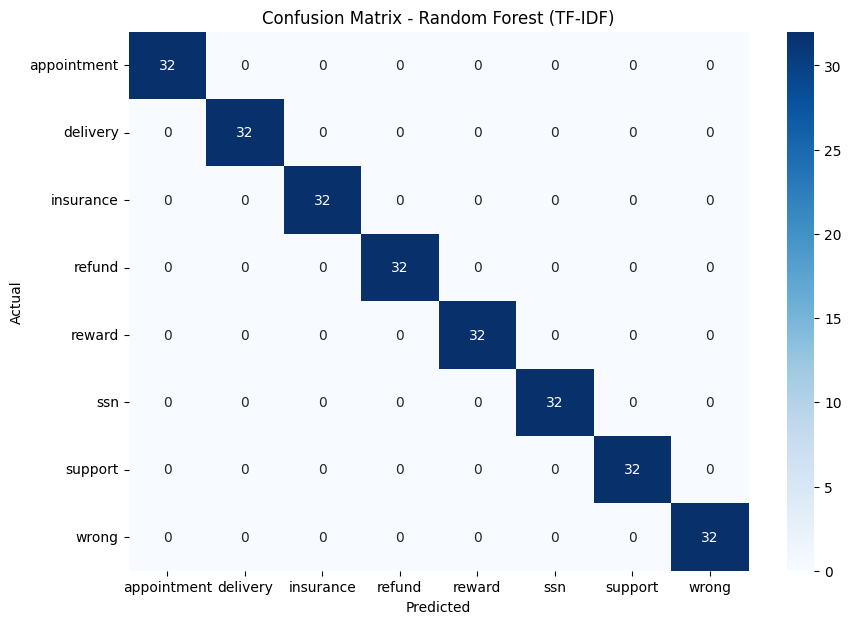

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Initialize and train the model
rf_tfidf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_tfidf.fit(X_train_tfidf, y_train)

# 2. Predictions
y_pred_tfidf = rf_tfidf.predict(X_test_tfidf)

# 3. Evaluation
print(f"Accuracy (TF-IDF): {accuracy_score(y_test, y_pred_tfidf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tfidf))

# 4. Confusion Matrix Visualization
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred_tfidf)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=rf_tfidf.classes_, yticklabels=rf_tfidf.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest (TF-IDF)')
plt.show()

### Investigando Possível Data Leakage
Vamos verificar se as palavras que definem os nomes das classes estão presentes no vocabulário e quão importantes elas são para o modelo Random Forest.

In [24]:
import pandas as pd

# 1. Pegar a importância das features do Random Forest
importances = rf_tfidf.feature_importances_
feature_names = tfidf_vectorizer.get_feature_names_out()

# 2. Criar um DataFrame com as top features
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

print("Top 20 features mais importantes para o modelo:")
display(feature_importance_df.head(20))

# 3. Verificar se os nomes das classes estão no vocabulário
class_names = [str(c).lower() for c in rf_tfidf.classes_]
found_classes = [word for word in class_names if word in feature_names]

print(f"\nNomes de classes encontrados no vocabulário do TF-IDF: {found_classes}")

Top 20 features mais importantes para o modelo:


,feature,importance
4180,refund,0.017280
2546,hey,0.014367
852,appointment,0.013041
3944,process,0.012891
4494,security,0.011734
4718,speedy,0.011594
4922,sweepstakes,0.011353
4659,social,0.011350
1755,dial,0.011166
5529,winner,0.010203



Nomes de classes encontrados no vocabulário do TF-IDF: ['appointment', 'delivery', 'insurance', 'refund', 'reward', 'ssn', 'support', 'wrong']
